# [Umar Jamil's Coding a Multimodal Vision Language Model from Scratch](https://www.youtube.com/watch?v=vAmKB7iPkWw)

* coding PaliGemma vision encoder, projector, language model, token combinations, and output generation.

* this is a lamguage model that can extract information from images. 

* from our other topic reviews, we know that `PaliGemma` is a unified embedding decoder architecture where visual tokens get projected and concatenated with text tokens and all are fed into a single decoder. 

* also called conditional generation

### Topics

1. Vision Transformer 
2. Contrastive LEarning (CLIP and SigLip)
3. Language Model (Gemma)
4. KV-Cache
5. Rotary Positional Embedding
6. Normalization (Batch, Layer, and RMS)

### Diving into Visual Encoder (contrastive)

* This is the CLIP part of our notebooks. 

#### What is contrastive learning?

* get a [NxN] similarity matrix od image-text pairs. We encode the text and the image, then do cosine similaorty of their emebeddings and expect pairs to end up with high similarity and all other with lower similarity.

* an embedding is a vector that captures the essence of the text or the image. 

* image-description dataset. 

* 

The expected, contrastive trained similaoirty matrix should look like the followins, where each row is an image each column is a text caption, and the values in the cells are the cosine similarity of the pairs. Dot product of an aimge with a text that doesnt corepsond to that image, it should produce a low value. 

We need to find a dot product that gives us a similarity matrix like the below. 

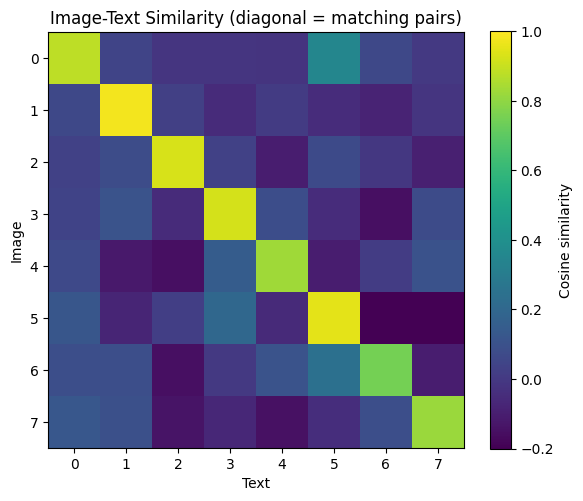

In [2]:
import torch                                                                                                                                                  
import matplotlib.pyplot as plt                                                                                                                             
                                                                                                                                                            
N = 8                                                                                                                                                         
# Start with small random values, add identity to boost diagonal                                                                                              
sim_matrix = torch.randn(N, N) * 0.1 + torch.eye(N) * 0.8                                                                                                     
                                                                                                                                                            
plt.figure(figsize=(6, 5))                                                                                                                                    
plt.imshow(sim_matrix, cmap='viridis', vmin=-0.2, vmax=1.0)                                                                                                   
plt.colorbar(label='Cosine similarity')                                                                                                                       
plt.xlabel("Text")
plt.ylabel("Image")                                                                                                                                           
plt.title("Image-Text Similarity (diagonal = matching pairs)")                                                                                                
plt.tight_layout()                                                                                                                                            
plt.show()

We use cross-entropy loss to achieve this. If we have a sample similarity matrix before training and after training, we can see how the loss is very different. And this loss will help us achieve the results we want. 


* The labels are simply the diagonal. `labels = torch.arange(logits.shape[0], device=logits.device)`

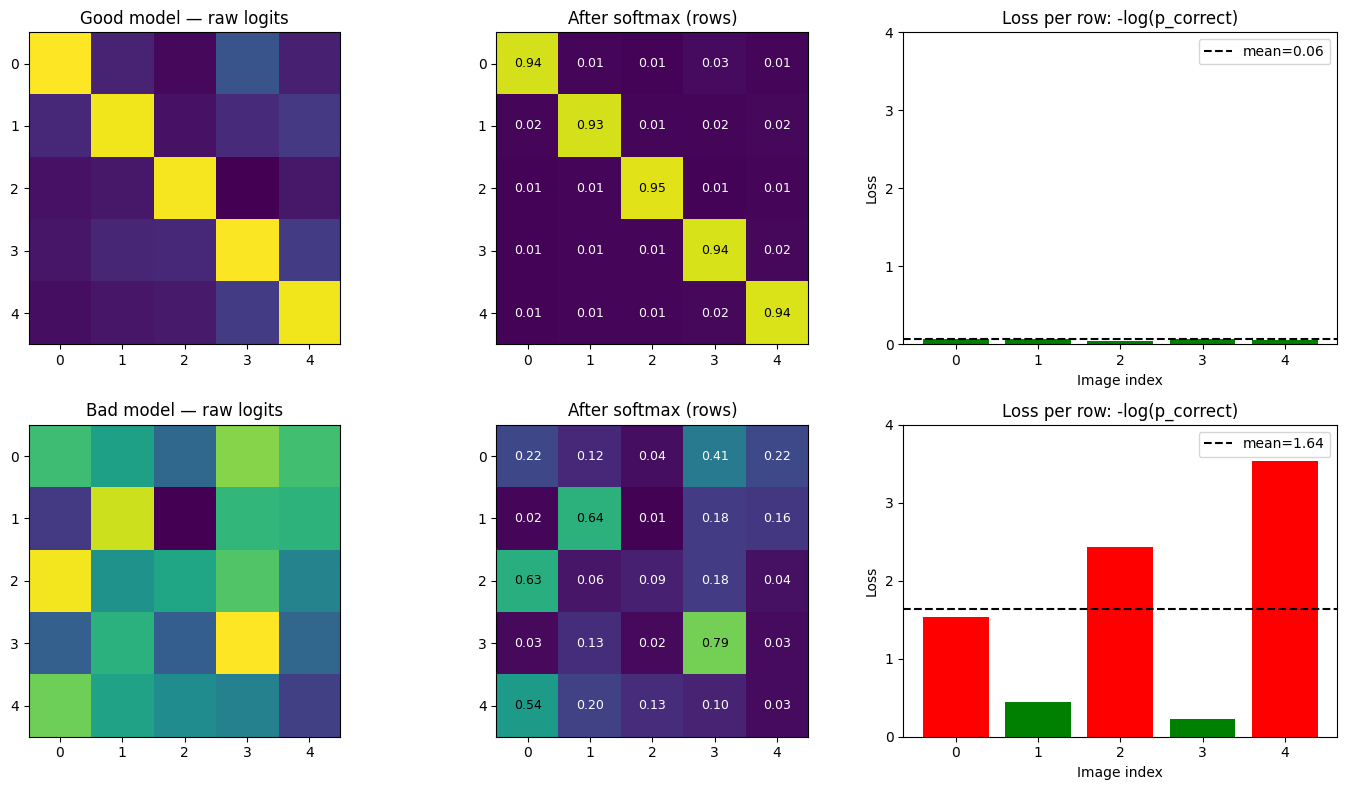

In [3]:
import torch                                                                                                                                                  
import torch.nn.functional as F                                                                                                                             
import matplotlib.pyplot as plt                                                                                                                               
                                                                                                                                                            
# Simulate a 5x5 similarity matrix (logits) — like CLIP produces                                                                                              
# Good model: diagonal is highest                                                                                                                           
logits_good = torch.eye(5) * 4.0 + torch.randn(5, 5) * 0.3                                                                                                    
# Bad model: random, no structure                                                                                                                             
logits_bad = torch.randn(5, 5)                                                                                                                                
                                                                                                                                                            
labels = torch.arange(5)  # correct match: image i → text i                                                                                                   
                                                                                                                                                            
# Cross-entropy converts logits → softmax probabilities, then penalizes                                                                                       
# based on how much probability lands on the correct label                                                                                                  
                                                                                                                                                            
fig, axes = plt.subplots(2, 3, figsize=(14, 8))                                                                                                               
                                                                                                                                                            
for i, (logits, name) in enumerate([(logits_good, "Good model"), (logits_bad, "Bad model")]):                                                                 
    # Raw logits                                                                                                                                            
    axes[i, 0].imshow(logits, cmap='viridis')                                                                                                                 
    axes[i, 0].set_title(f"{name} — raw logits")                                                                                                              

    # After softmax (per row) — this is what cross-entropy does internally                                                                                    
    probs = F.softmax(logits, dim=-1)                                                                                                                       
    axes[i, 1].imshow(probs, cmap='viridis', vmin=0, vmax=1)                                                                                                  
    axes[i, 1].set_title(f"After softmax (rows)")                                                                                                             
    # Annotate probabilities                                                                                                                                  
    for r in range(5):                                                                                                                                        
        for c in range(5):                                                                                                                                    
            color = 'white' if probs[r, c] < 0.5 else 'black'                                                                                                 
            axes[i, 1].text(c, r, f"{probs[r, c]:.2f}", ha='center', va='center', color=color, fontsize=9)                                                    
                                                                                                                                                            
    # Per-row loss: -log(probability of correct class)                                                                                                        
    row_losses = [-torch.log(probs[r, labels[r]]).item() for r in range(5)]                                                                                   
    axes[i, 2].bar(range(5), row_losses, color=['green' if l < 0.5 else 'red' for l in row_losses])                                                           
    axes[i, 2].set_title(f"Loss per row: -log(p_correct)")                                                                                                    
    axes[i, 2].set_ylabel("Loss")                                                                                                                             
    axes[i, 2].set_xlabel("Image index")                                                                                                                      
                                                                                                                                                            
    loss = F.cross_entropy(logits, labels)                                                                                                                    
    axes[i, 2].axhline(y=loss.item(), color='black', linestyle='--', label=f"mean={loss.item():.2f}")                                                       
    axes[i, 2].legend()                                                                                                                                       
                                                                                                                                                            
for ax in axes.flat:                                                                                                                                          
    ax.set_xticks(range(5))                                                                                                                                 
    ax.set_yticks(range(5))                                                                                                                                   
                                                                                                                                                            
plt.tight_layout()                                                                                                                                            
plt.show()

### What are some problems with CLIP?

* cross-entropy loss. We compute logits that are transformed into a distribution. 
* softmax function takes logits and converts into distribution. 
* take the ouput of the model, we exponentiate it, and then divide by the sum of all the items. 
* need for each row, the exponentials of the items, then divide by the sum of the exponential of all the items.
* exponential function grows very fast. Since we use a fixed represnetation like 32-bit, this might become a problem. if exponential is too big, then it might not be represented well and we need to add **numerical stability**
* pytorch uses the normalization constant, so it takes care of that issue for us. PyTorch's F.cross_entropy uses the log-sum-exp trick internally (subtract the max first)
* This is also why **SigLIP replaces the softmax with a sigmoid**. They signmoid each pair independently. It also helps us parallelize so that we dont need the entire row or column across devices. Should help us increase batch size too. 
* With SigLIP, we take the similarity matrix [NxN] with all the dot products. Instead of trying to maximize the values across the diagonal, we use a kind of binary classifier using sigmoid loss. 
* each dot product is independent of each other. Every row then has one 'true ground truth' value across the diagonal and everything else is a 'wrong classification'.
* each dot product is run through a signmoid and force labels to be 1 for true diagonal and everything is wrong. No more normalization constant nor maximum values.

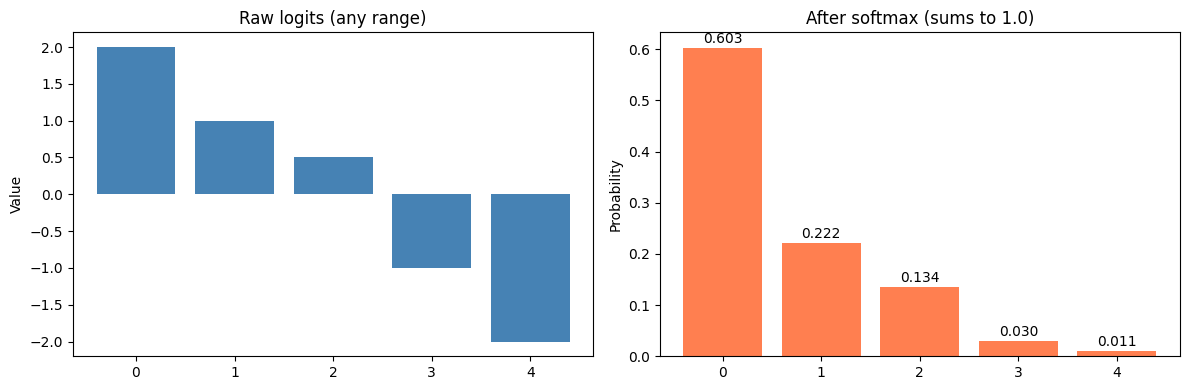

Softmax step by step:
  logits:      [2.0, 1.0, 0.5, -1.0, -2.0]
  exp(logits): [7.389056205749512, 2.7182817459106445, 1.6487212181091309, 0.3678794503211975, 0.1353352814912796]
  sum of exp:  12.2593
  softmax:     [0.6027319431304932, 0.22173269093036652, 0.13448767364025116, 0.030008256435394287, 0.01103942096233368]
  sum:         1.0000


In [4]:
## How does softmax work again?

logits = torch.tensor([2.0, 1.0, 0.5, -1.0, -2.0])                                                                                                          
                                                                                                                                                            
# Softmax: exp(each) / sum(exp(all)) → probabilities that sum to 1                                                                                            
probs = F.softmax(logits, dim=-1)                                                                                                                             
                                                                                                                                                            
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                                                                                                               

axes[0].bar(range(5), logits, color='steelblue')                                                                                                              
axes[0].set_title("Raw logits (any range)")                                                                                                                 
axes[0].set_ylabel("Value")                                                                                                                                   
                                                                                                                                                            
axes[1].bar(range(5), probs, color='coral')                                                                                                                   
axes[1].set_title("After softmax (sums to 1.0)")                                                                                                            
axes[1].set_ylabel("Probability")                                                                                                                             
for i, p in enumerate(probs):                                                                                                                               
    axes[1].text(i, p + 0.01, f"{p:.3f}", ha='center', fontsize=10)                                                                                           
                                                                                                                                                            
plt.tight_layout()                                                                                                                                            
plt.show()                                                                                                                                                    
                                                                                                                                                            
# Show the math explicitly                                                                                                                                    
print("Softmax step by step:")                                                                                                                                
print(f"  logits:      {logits.tolist()}")                                                                                                                    
print(f"  exp(logits): {torch.exp(logits).tolist()}")                                                                                                         
print(f"  sum of exp:  {torch.exp(logits).sum().item():.4f}")                                                                                                 
print(f"  softmax:     {probs.tolist()}")                                                                                                                     
print(f"  sum:         {probs.sum().item():.4f}") 

CLIP loss (softmax CE):     0.5566
SigLIP loss (sigmoid BCE):  0.6162


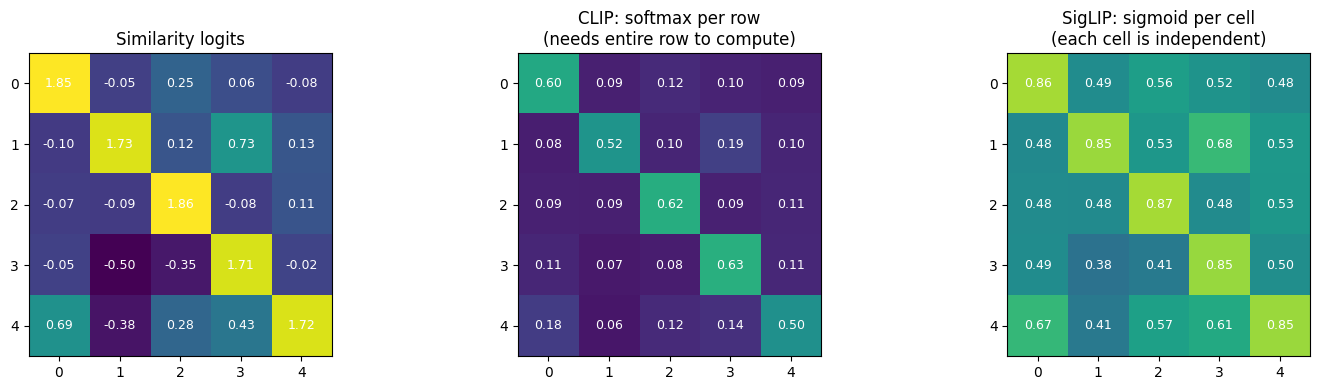

=== Why SigLIP scales better ===

CLIP softmax for cell (2,3):
  needs: exp(logit[2,3]) / (exp(logit[2,0]) + exp(logit[2,1]) + ... + exp(logit[2,N]))
  → must have ALL logits in row 2 on the SAME device

SigLIP sigmoid for cell (2,3):
  needs: sigmoid(logit[2,3]) = 1 / (1 + exp(-logit[2,3]))
  → only needs THIS ONE value, can be on ANY device


In [5]:
N = 5                                                                                                                                                         
# Fake similarity matrix (logits)                                                                                                                           
logits = torch.randn(N, N) * 0.3 + torch.eye(N) * 2.0                                                                                                         
                                                                                                                                                            
# === CLIP loss: softmax cross-entropy (global normalization) ===                                                                                             
labels_clip = torch.arange(N)                                                                                                                                 
clip_loss_i = F.cross_entropy(logits, labels_clip)                                                                                                            
clip_loss_t = F.cross_entropy(logits.T, labels_clip)                                                                                                          
clip_loss = (clip_loss_i + clip_loss_t) / 2                                                                                                                   
                                                                                                                                                            
# === SigLIP loss: sigmoid binary cross-entropy (per-pair, independent) ===                                                                                   
# Labels: +1 on diagonal (match), -1 off diagonal (no match)                                                                                                  
labels_sig = 2 * torch.eye(N) - 1  # +1 for match, -1 for mismatch                                                                                            
                                                                                                                                                            
# Each pair independently: sigmoid(-label * logit)                                                                                                            
# This pushes matching pairs toward +inf and non-matching toward -inf                                                                                         
siglip_loss = -F.logsigmoid(labels_sig * logits).mean()                                                                                                       
                                                                                                                                                            
print(f"CLIP loss (softmax CE):     {clip_loss.item():.4f}")                                                                                                  
print(f"SigLIP loss (sigmoid BCE):  {siglip_loss.item():.4f}")                                                                                                
                                                                                                                                                            
# Visualize the difference                                                                                                                                    
fig, axes = plt.subplots(1, 3, figsize=(15, 4))                                                                                                               
                                                                                                                                                            
# Raw logits    
axes[0].imshow(logits, cmap='viridis')
axes[0].set_title("Similarity logits")
for r in range(N):                                                                                                                                            
    for c in range(N):                                                                                                                                        
        axes[0].text(c, r, f"{logits[r,c]:.2f}", ha='center', va='center', color='white', fontsize=9)                                                         
                                                                                                                                                            
# CLIP: softmax probabilities (each row sums to 1 — needs full row)                                                                                           
clip_probs = F.softmax(logits, dim=-1)                                                                                                                        
axes[1].imshow(clip_probs, cmap='viridis', vmin=0, vmax=1)                                                                                                    
axes[1].set_title("CLIP: softmax per row\n(needs entire row to compute)")
for r in range(N):                                                                                                                                            
    for c in range(N):
        axes[1].text(c, r, f"{clip_probs[r,c]:.2f}", ha='center', va='center', color='white', fontsize=9)                                                     
                                                                                                                                                            
# SigLIP: sigmoid per cell (independent, no normalization)                                                                                                    
sig_probs = torch.sigmoid(logits)                                                                                                                             
axes[2].imshow(sig_probs, cmap='viridis', vmin=0, vmax=1)                                                                                                     
axes[2].set_title("SigLIP: sigmoid per cell\n(each cell is independent)")                                                                                     
for r in range(N):                                                                                                                                            
    for c in range(N):                                                                                                                                        
        axes[2].text(c, r, f"{sig_probs[r,c]:.2f}", ha='center', va='center', color='white', fontsize=9)                                                      
                                                                                                                                                            
plt.tight_layout()                                                                                                                                            
plt.show()                                                                                                                                                    
                                                                                                                                                            
# Show WHY independence matters for parallelism                                                                                                               
print("=== Why SigLIP scales better ===\n")                                                                                                                   
print("CLIP softmax for cell (2,3):")                                                                                                                         
print(f"  needs: exp(logit[2,3]) / (exp(logit[2,0]) + exp(logit[2,1]) + ... + exp(logit[2,N]))")                                                              
print(f"  → must have ALL logits in row 2 on the SAME device\n")                                                                                              
                                                                                                                                                            
print("SigLIP sigmoid for cell (2,3):")                                                                                                                       
print(f"  needs: sigmoid(logit[2,3]) = 1 / (1 + exp(-logit[2,3]))")                                                                                           
print(f"  → only needs THIS ONE value, can be on ANY device") 

ok, but why contrastive? So we can align text to images. 